In [1]:
import tensorflow  as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [ ]:
DATASET_DIR = "../data/raw/PlantVillage/"
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # EfficientNet standard

In [13]:
import cv2

def find_and_clean_segmented_images(directory, black_threshold=0.1):
    print("Scanning...")
    suspect_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, file)

                img = cv2.imread(filepath)
                if img is None:
                    continue

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                black_pixels = np.sum(gray <= 5)
                total_pixels = gray.shape[0] * gray.shape[1]

                if (black_pixels / total_pixels) > black_threshold:
                    suspect_files.append(filepath)
    
    return suspect_files

In [14]:
bad_images = find_and_clean_segmented_images(DATASET_DIR)
print(f"Found {len(bad_images)} segmented images")

import shutil
trash_dir = "../data/raw/Trash_Segmented/"
os.makedirs(trash_dir, exist_ok=True)

for file in bad_images:
    filename = os.path.basename(file)
    shutil.move(file, os.path.join(trash_dir, filename))

print("Cleaning complete")

Scanning...
Found 201 segmented images
Cleaning complete


In [4]:
classes = os.listdir(DATASET_DIR)
print(f"Found {len(classes)} classes")

Found 19 classes


In [15]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 25297 files belonging to 19 classes.
Using 20238 files for training.
Found 25297 files belonging to 19 classes.
Using 5059 files for validation.



 List of labels will be added to the app.


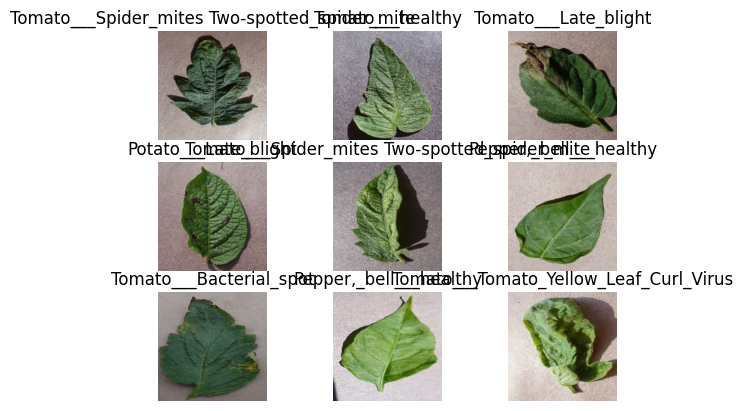

In [16]:
class_names = train_dataset.class_names

print("\n List of labels will be added to the app.")
for image, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)

        plt.imshow(image[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [17]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
])

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(19, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19)             │        24,339 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,073,910 (15.54 MB)

 Trainable params: 24,339 (95.07 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

os.makedirs('../models', exist_ok=True)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='../models/best_agrivision_tf.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# Stop if accuracy freezes after 5 epochs
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Init Optimizer and Callbacks!")

Init Optimizer and Callbacks!


In [19]:
EPOCHS = 20

print("Training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Training...
Epoch 1/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.6487 - loss: 1.2389
Epoch 1: val_accuracy improved from None to 0.88733, saving model to ../models/best_agrivision_tf.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 286s 443ms/step - accuracy: 0.7830 - loss: 0.7900 - val_accuracy: 0.8873 - val_loss: 0.4298
Epoch 2/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8882 - loss: 0.3926
Epoch 2: val_accuracy improved from 0.88733 to 0.90927, saving model to ../models/best_agrivision_tf.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 277s 438ms/step - accuracy: 0.8943 - loss: 0.3706 - val_accuracy: 0.9093 - val_loss: 0.3231
Epoch 3/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9122 - loss: 0.3028
Epoch 3: val_accuracy improved from 0.90927 to 0.91817, saving model to ../models/best_agrivision_tf.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 277s 438ms/step - accuracy: 0.9119 - loss: 0.3001 - val_accuracy: 0.9182 - val_loss: 0.2766
Epoch 4/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 

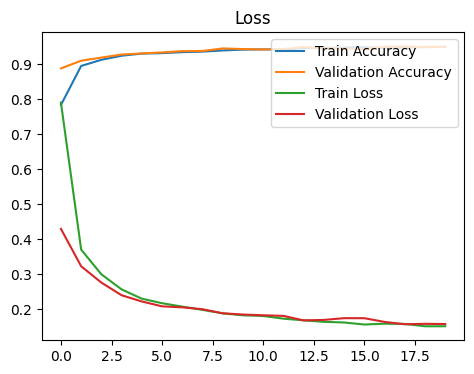

In [20]:
# Draw chart
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1, 2, 1)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()


In [ ]:
# Convert to TFLITE
print("\nConverting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = '../model/agrivision_tf_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print("Done.")